# Energy-Aware Scheduling Simulation

Tests whether cross-architecture energy predictions can guide task placement to reduce total energy consumption. Candidate architectures are the two Augur clusters (gu = older Xeon E5-2640 v2, hu = newer Xeon Scalable), which have genuinely different energy profiles.

**Approach:** the model predicts each task's energy on each architecture and picks the cheaper one (realistic deployment). Placements are scored on ground-truth energy, and compared against naive baselines and an oracle (best-possible placement).

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

## 2. Load data and build the ground-truth energy table

Restrict to Augur tasks with measured energy, tag each with its architecture (gu/hu) and normalised task type, then compute median energy per (task_type, architecture). Keeping only task types present on **both** architectures ensures every scheduling decision is a real choice.

In [2]:
df = pd.read_csv("../Processed_data/unified_data_new.csv")

aug = df[(df["source_dataset"].isin(["augur_gu", "augur_hu"])) & (df["energy_j"] > 0)].copy()
aug["arch"] = aug["source_dataset"].map({"augur_gu": "gu", "augur_hu": "hu"})
aug["task_type"] = aug["process"].str.split(":").str[-1].str.upper()

truth = aug.groupby(["task_type", "arch"])["energy_j"].median().unstack().dropna()   # FIXED: reassigned
print(f"{len(truth)} task types with energy on both architectures")
truth.head()

80 task types with energy on both architectures


arch,gu,hu
task_type,,
ANNOTATE_BOOLEAN_PEAKS,62.74005,139.291775
BAMBU,304680.53450,194340.822300
BAMTOOLS_FILTER,18549.44630,12192.325575
BAM_FILTER,25125.23175,22193.339700
BAM_REMOVE_ORPHANS,3633.48435,215.575300


## 3. Is the scheduling choice non-trivial?

If one architecture were always cheaper, scheduling would be trivial. A mixed split means the energy-optimal architecture genuinely depends on the task — which is what makes per-task prediction valuable.

In [3]:
truth["cheaper"] = np.where(truth["gu"] < truth["hu"], "gu", "hu")
print(truth["cheaper"].value_counts())

cheaper
hu    51
gu    29
Name: count, dtype: int64


## 4. Train the energy model and run the simulation

Train a Random Forest energy predictor on all Augur tasks. For each task, predict its energy on gu and on hu (by substituting each architecture's hardware features), and pick the cheaper. Compare five strategies:

- **random** / **round_robin** — energy-blind baselines
- **always_hu** — the simple 'use the newer cluster' heuristic
- **model** — our prediction-guided placement
- **oracle** — best-possible placement using ground-truth energy (the ceiling)

In [4]:
# --- Features + train energy model on all Augur data ---
base_features = ["rchar", "cpus", "cores", "ram", "cpu_benchmark", "io_read", "io_write"]
d = aug.dropna(subset=["energy_j"] + base_features).copy()
d = d[d["energy_j"] > 0]
d = pd.get_dummies(d, columns=["task_type"], prefix="task")
task_cols = [c for c in d.columns if c.startswith("task_")]
feats = base_features + task_cols

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(d[feats], d["energy_j"])

# --- Representative hardware specs per architecture ---
gu_specs = aug[aug["arch"]=="gu"][["cores","ram","cpu_benchmark","io_read","io_write"]].median()
hu_specs = aug[aug["arch"]=="hu"][["cores","ram","cpu_benchmark","io_read","io_write"]].median()

# --- Predict each task's energy on gu and on hu ---
def predict_on_arch(data, specs):
    X = data[feats].copy()
    for col in ["cores","ram","cpu_benchmark","io_read","io_write"]:
        X[col] = specs[col]
    return model.predict(X)

d["pred_gu"] = predict_on_arch(d, gu_specs)
d["pred_hu"] = predict_on_arch(d, hu_specs)

# --- Ground-truth energy per (task_type, arch) for scoring ---
d["task_type"] = aug.loc[d.index, "task_type"]
truth_lookup = aug.groupby(["task_type","arch"])["energy_j"].median().unstack().dropna()
d_sim = d[d["task_type"].isin(truth_lookup.index)].copy()

# --- Apply each strategy per task, score on ground truth ---
np.random.seed(42)
rows = []
for i, (_, task) in enumerate(d_sim.iterrows()):
    tt = task["task_type"]
    gu_true, hu_true = truth_lookup.loc[tt, "gu"], truth_lookup.loc[tt, "hu"]
    choices = {
        "random":      np.random.choice(["gu","hu"]),
        "round_robin": ["gu","hu"][i % 2],
        "always_hu":   "hu",
        "model":       "gu" if task["pred_gu"] < task["pred_hu"] else "hu",
        "oracle":      "gu" if gu_true < hu_true else "hu",
    }
    for strat, arch in choices.items():
        rows.append({"strategy": strat, "energy": gu_true if arch=="gu" else hu_true})

sim = pd.DataFrame(rows)
totals = sim.groupby("strategy")["energy"].sum().sort_values()
print("Total energy by strategy (lower = better):")
print(totals, "\n")

rand = totals["random"]
print("Savings vs random:")
for strat in ["round_robin","always_hu","model","oracle"]:
    print(f"  {strat:12s}: {100*(rand-totals[strat])/rand:+.1f}%")

model_save, oracle_save = rand - totals["model"], rand - totals["oracle"]
print(f"\nModel captures {100*model_save/oracle_save:.1f}% of oracle's achievable savings")

Total energy by strategy (lower = better):
strategy
oracle         1.966178e+08
model          2.095716e+08
always_hu      2.159871e+08
round_robin    2.270908e+08
random         2.273701e+08
Name: energy, dtype: float64 

Savings vs random:
  round_robin : +0.1%
  always_hu   : +5.0%
  model       : +7.8%
  oracle      : +13.5%

Model captures 57.9% of oracle's achievable savings


## 5. Energy consumption by strategy

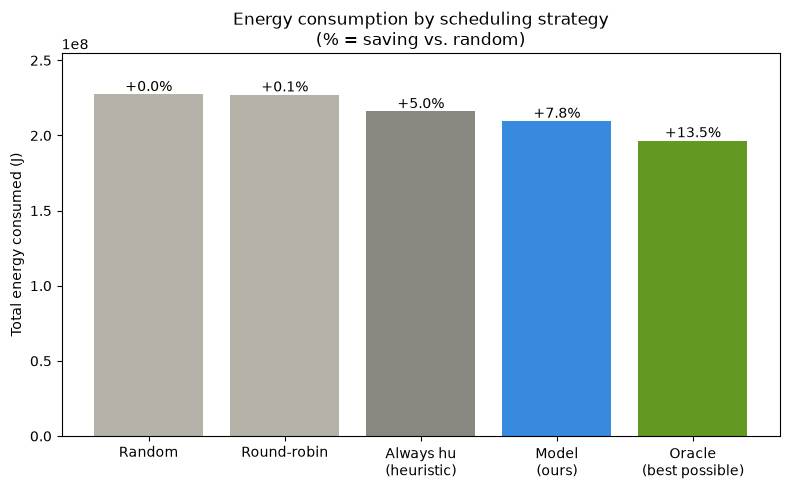

In [5]:
strat_order = ["random", "round_robin", "always_hu", "model", "oracle"]
labels = ["Random", "Round-robin", "Always hu\n(heuristic)", "Model\n(ours)", "Oracle\n(best possible)"]
values = [totals[s] for s in strat_order]
colors = ["#B4B2A9", "#B4B2A9", "#888780", "#378ADD", "#639922"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors)
for bar, s in zip(bars, strat_order):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
            f"{100*(rand-totals[s])/rand:+.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Total energy consumed (J)")
ax.set_title("Energy consumption by scheduling strategy\n(% = saving vs. random)")
ax.margins(y=0.12)
plt.tight_layout()
plt.savefig("../Processed_data/scheduling_barchart.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Routing analysis how the model decides

Per task type, compare the model's chosen architecture against the actually-cheaper one. The crosstab shows where the model agrees/disagrees with ground truth.

In [6]:
routing = truth_lookup.copy()
routing["actual_cheaper"] = np.where(routing["gu"] < routing["hu"], "gu", "hu")

model_choice = (
    d_sim.assign(model_pick=np.where(d_sim["pred_gu"] < d_sim["pred_hu"], "gu", "hu"))
         .groupby("task_type")["model_pick"].agg(lambda x: x.mode()[0])
)
routing["model_choice"] = model_choice
routing["correct"] = routing["model_choice"] == routing["actual_cheaper"]

print(f"{100*routing['correct'].mean():.1f}% of task types routed correctly\n")
print("How the model routed vs. what was actually cheaper:")
print(pd.crosstab(routing["actual_cheaper"], routing["model_choice"],
                  rownames=["actually cheaper"], colnames=["model chose"]))

73.8% of task types routed correctly

How the model routed vs. what was actually cheaper:
model chose       gu  hu
actually cheaper        
gu                19  10
hu                11  40


### Energy-weighted routing accuracy

Weighting each decision by the energy at stake reveals whether mis-routings fall on high- or low-impact task types. A weighted accuracy well above the raw accuracy means the model is right where it matters most.

In [7]:
routing["energy_gap"] = abs(routing["gu"] - routing["hu"])
weighted_acc = (routing["correct"] * routing["energy_gap"]).sum() / routing["energy_gap"].sum()
print(f"Raw routing accuracy:            {100*routing['correct'].mean():.1f}%")
print(f"Energy-weighted routing accuracy: {100*weighted_acc:.1f}%")

Raw routing accuracy:            73.8%
Energy-weighted routing accuracy: 90.6%


## 7.The power/time tradeoff

Energy = power x time. The newer hu cluster is faster but draws more power; the older gu cluster is slower but lower-power. This predicts that **short tasks** favour gu (hu's speed can't pay off) while **long tasks** favour hu (faster completion outweighs higher power). The plot tests this a tendency rather than a clean threshold, which itself motivates a multi-feature model over a simple runtime rule.

gu_cheaper
False    86250.0
True     25000.0
Name: median_runtime, dtype: float64


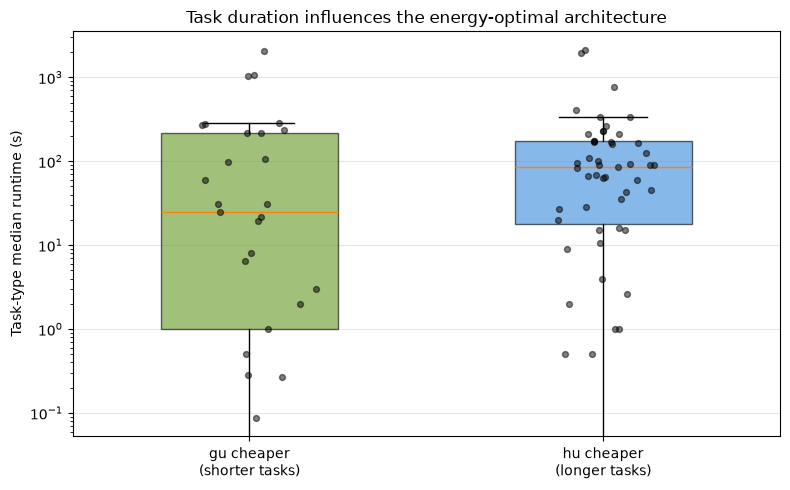

gu-cheaper: median runtime 25.0s (n=29)
hu-cheaper: median runtime 86.2s (n=51)


In [8]:
routing["gu_cheaper"] = routing["gu"] < routing["hu"]
routing["median_runtime"] = aug.groupby("task_type")["runtime_s"].median()
print(routing.groupby("gu_cheaper")["median_runtime"].median())

plot_df = routing.dropna(subset=["median_runtime"]).copy()
gu_rt = plot_df[plot_df["gu_cheaper"]]["median_runtime"] / 1000
hu_rt = plot_df[~plot_df["gu_cheaper"]]["median_runtime"] / 1000

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([gu_rt, hu_rt], patch_artist=True, widths=0.5, showfliers=False)
for patch, color in zip(bp["boxes"], ["#639922", "#378ADD"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
for i, data in enumerate([gu_rt, hu_rt], start=1):
    ax.scatter(np.random.normal(i, 0.06, size=len(data)), data, alpha=0.5, color="black", s=18, zorder=3)

ax.set_xticks([1, 2])
ax.set_xticklabels(["gu cheaper\n(shorter tasks)", "hu cheaper\n(longer tasks)"])   # FIXED labels
ax.set_ylabel("Task-type median runtime (s)")
ax.set_title("Task duration influences the energy-optimal architecture")
ax.set_yscale("log")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../Processed_data/power_time_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"gu-cheaper: median runtime {gu_rt.median():.1f}s (n={len(gu_rt)})")
print(f"hu-cheaper: median runtime {hu_rt.median():.1f}s (n={len(hu_rt)})")